# 11 — The structural layer: USDCAD on the rate differential and oil

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mamadouyamar/CVineMarketGen/blob/main/examples/11_structural_layer_fx.ipynb)

Some variables are functions of others. The Canadian dollar follows the
interest-rate differential with the United States and the price of oil. In the
market such a variable is a *child*: it follows a structural equation on its
*parents* plus its own innovation, and that innovation is its residual layer.
The parents are simulated first, by their own models (here a block, as in
notebook 10), and the child is rebuilt from their paths and from its own draw.
The equation is an error-correction model in levels: a long-run relation the
child returns to, a contemporaneous response to the parents' changes, and the
speed of the return.

Runtime: about 5 minutes.

## Import

In [1]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "examples" else os.getcwd()
sys.path.insert(0, ROOT)                 # run from a local clone, from examples/ or the root
try:
    import cvinemarketgen                # local clone or already installed
except ImportError:                      # e.g. on Google Colab
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/mamadouyamar/CVineMarketGen.git[garch,blocks]"], check=True)
    import cvinemarketgen
print("cvinemarketgen", cvinemarketgen.__version__)

for pkg in ("arch", "statsmodels"):
    try:
        __import__(pkg)
    except ImportError:
        import subprocess; subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)
from cvinemarketgen import load_fred_monthly, load_etf_monthly, Targets, CVineMarket, Structural, iid_tests

cvinemarketgen 0.3.0


## Load

FRED monthly averages: USDCAD (Canadian dollars per U.S. dollar), the U.S. and Canadian 10-year government yields, and WTI crude. The child is the log exchange rate $s_t = \log S_t$; the parents are $\mathbf z_t = (z_{1t}, z_{2t})'$ with the yield differential $z_{1t} = y^{US}_t - y^{CA}_t$ (U.S. minus Canada, percent) and the log oil price $z_{2t} = \log O_t$. Logs make the exchange rate's and oil's changes percentage changes, $\Delta s_t \approx (S_t - S_{t-1}) / S_{t-1}$, and put the two on the scale a linear equation expects. SPY's monthly return $r_t$ comes along as an asset, aligned on the common months.

In [2]:
raw = load_fred_monthly(["DEXCAUS", "DGS10", "IRLTLT01CAM156N", "DCOILWTICO"], start="2003-01", cache=os.path.join(ROOT, "data", "fred_cache.csv"))
spy = load_etf_monthly(["SPY"], cache=os.path.join(ROOT, "data", "etf_cache.csv"))
data = pd.DataFrame({"log_fx": np.log(raw["DEXCAUS"]), "rate_diff": raw["DGS10"] - raw["IRLTLT01CAM156N"], "log_oil": np.log(raw["DCOILWTICO"])}).join(spy, how="inner")
print(data.shape[0], "months,", data.index.min(), "to", data.index.max())
data.tail()

FRED series read from cache /Users/mamadouthioub/Desktop/CopulaGenerator/CVineMarketGen/data/fred_cache.csv: 284 months, 2003-01 to 2026-08
ETF returns read from cache /Users/mamadouthioub/Desktop/CopulaGenerator/CVineMarketGen/data/etf_cache.csv: 232 months, 2007-06 to 2026-09
231 months, 2007-06 to 2026-08


,log_fx,rate_diff,log_oil,SPY
month,,,,
2026-04,0.318768,0.800758,4.608332,0.105053
2026-05,0.316054,0.942500,4.626286,0.052626
2026-06,0.338871,1.082143,4.440380,-0.010293
2026-07,0.343918,1.052273,4.387715,0.000348
2026-08,0.329465,1.009286,4.429597,0.026799


The child and its parents in levels. The three series are integrated of order one, $s_t = s_{t-1} + \Delta s_t$ with a stationary $\Delta s_t$, so they wander without a fixed mean over the sample; that is why the child's equation is written in error-correction form on levels rather than as a regression of returns on returns: the levels can share a long-run relation $s_t \approx \text{const} + \boldsymbol\theta' \mathbf z_t$ that the changes alone do not show.

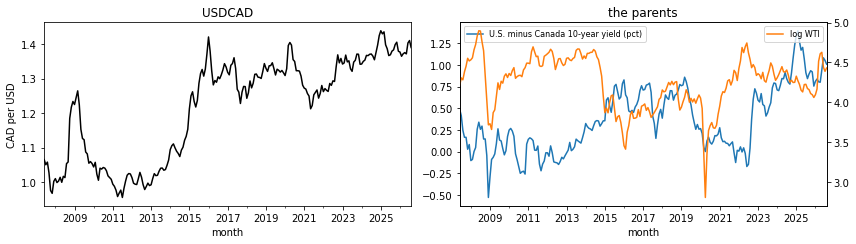

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
np.exp(data["log_fx"]).plot(ax=axes[0], color="black"); axes[0].set_title("USDCAD"); axes[0].set_ylabel("CAD per USD")
data["rate_diff"].plot(ax=axes[1], label="U.S. minus Canada 10-year yield (pct)"); ax2 = axes[1].twinx(); data["log_oil"].plot(ax=ax2, color="tab:orange", label="log WTI")
axes[1].legend(loc="upper left", fontsize=8); ax2.legend(loc="upper right", fontsize=8); axes[1].set_title("the parents"); plt.tight_layout(); plt.show()

## The error-correction equation

`Structural` fits, by least squares, the single-equation error-correction model

$$\Delta s_t = c + \kappa\, s_{t-1} + \mathbf b' \mathbf z_{t-1} + \boldsymbol\gamma' \Delta \mathbf z_t + \phi\, \Delta s_{t-1} + \sigma\, \varepsilon_t,$$

with $\mathbf z = (\text{rate\_diff}, \text{log\_oil})'$. In matrix form $\mathbf y = \mathbf X \boldsymbol\beta + \mathbf e$ with $\mathbf y = (\Delta s_t)$, the columns of $\mathbf X$ the constant, $s_{t-1}$, $\mathbf z_{t-1}$, $\Delta \mathbf z_t$ and $\Delta s_{t-1}$, $\hat{\boldsymbol\beta} = (\mathbf X'\mathbf X)^{-1}\mathbf X'\mathbf y$, $\hat\sigma^2 = \mathbf e'\mathbf e / (n - k)$, standard errors from $\hat\sigma^2 (\mathbf X'\mathbf X)^{-1}$ and $t = \hat\beta_j / \mathrm{se}_j$. $\kappa$ is the speed of adjustment (negative when the child returns to its long-run level), $\boldsymbol\theta = -\mathbf b / \kappa$ the long-run relation, $\boldsymbol\gamma$ the response to this month's change of the parents, $\phi$ the momentum of the child's own change, and $\varepsilon_t = e_t / \hat\sigma$ the child's residual layer. $R^2$ is that of the regression of $\Delta s_t$; the half-life of a deviation from the long-run relation is $\ln(1/2) / \ln(1 + \kappa)$ months.

In [4]:
m = Structural(["rate_diff", "log_oil"], form="ecm", lags=1).fit(data["log_fx"], data[["rate_diff", "log_oil"]])
print(m.name, "| kappa", round(m.kappa, 4), "| half-life", round(m.half_life, 1), "months | R2", round(m.r2, 3), "| sigma", round(m.sigma, 4))
coef = pd.Series({"const": m.const, "s_l1": m.kappa, "rate_diff_l1": m.b["rate_diff"], "log_oil_l1": m.b["log_oil"],
                  "d_rate_diff": m.gamma["rate_diff"], "d_log_oil": m.gamma["log_oil"], "d_s_l1": m.phi[0]})
pd.DataFrame({"coefficient": coef, "t": m.tstat.reindex(coef.index)}).round(4)

ECM(log_fx | rate_diff, log_oil) | kappa -0.0174 | half-life 39.5 months | R2 0.346 | sigma 0.0152


,coefficient,t
const,-0.0066,-0.3477
s_l1,-0.0174,-1.1774
rate_diff_l1,0.0039,0.9458
log_oil_l1,0.0022,0.5355
d_rate_diff,0.0536,5.1992
d_log_oil,-0.0814,-8.2939
d_s_l1,0.1177,2.0640


The long-run relation: set $\Delta s_t = 0$, $\Delta \mathbf z_t = 0$ and $\varepsilon_t = 0$ in the equation to get $0 = c + \kappa s + \mathbf b' \mathbf z$, that is $s = -(c + \mathbf b' \mathbf z) / \kappa = \text{const} + \boldsymbol\theta' \mathbf z$ with $\boldsymbol\theta = -\mathbf b / \kappa$. Each $\theta_j$ is the long-run elasticity of log USDCAD to parent $j$: a permanent one-unit rise of the yield differential (one percentage point) or of log oil (100 percent) moves the level of $s$ by $\theta_j$ once the adjustment is complete. Their precision is that of the ratio of two least-squares coefficients, and inherits the imprecision of $\kappa$.

In [5]:
m.theta.rename("long-run elasticity of log USDCAD").round(3)

rate_diff    0.225
log_oil      0.128
Name: long-run elasticity of log USDCAD, dtype: float64

A one-point wider U.S. yield advantage raises the long-run level of USDCAD;
the oil coefficient in the long-run relation is small, oil acts through the
contemporaneous change: a rise in oil strengthens the Canadian dollar that
month (negative `d_log_oil`). The adjustment is slow, a half-life of a few
years, as exchange rates are, and its coefficient is weakly identified
($t = -1.2$): on 19 years of monthly data the long-run relation is imprecise,
whereas the short-run responses to the yield differential and to oil are
sharp ($t$ of 5 and $-8$).

## The child's residual layer

The standardized innovation of the equation, $\varepsilon_t = e_t / \hat\sigma$, with $e_t$ the least-squares residual. By construction it has mean zero and is orthogonal to every regressor, in particular to $\Delta \mathbf z_t$: in sample its correlation with the parents' contemporaneous changes is exactly zero, and the link between child and parents lives in $\boldsymbol\gamma$ and $\boldsymbol\theta$, not in the copula. It is tested like any other residual, Ljung-Box $Q_{20} = n(n+2)\sum_{j \le 20}\hat\rho_j^{\,2}/(n-j)$ on $\varepsilon_t$ and on $\varepsilon_t^2$, and the ARCH-LM statistic $n R^2$ of $\varepsilon_t^2$ on its 20 lags, all $\chi^2_{20}$, and it is what the vine joins to the parents' innovations and to SPY. Read the tests: no autocorrelation is left, but the squares and the ARCH test reject, so the innovation clusters its variance. The equation has no GARCH term; an ECM with GARCH innovations is the natural next candidate.

In [6]:
z = m.filter()
pd.Series(iid_tests(z.values), name="p-value").round(3)

lb_z       0.507
lb_z2      0.020
arch_lm    0.000
Name: p-value, dtype: float64

The moments of the residual layer: mean 0 and standard deviation 1 up to the degrees-of-freedom correction, and the skewness and kurtosis that become the targets of the Johnson SU marginal of this column, $\varepsilon = q(Z) = \xi + \lambda \sinh((Z - \gamma)/\delta)$ with $(\gamma, \xi, \delta, \lambda)$ solving the four moment equations (the kurtosis is floored at $3.1 + 2\gamma_1^2$ if it falls below the family's boundary). The minimum and maximum say how far the tails reach in standard deviations.

In [7]:
z.describe().round(3)

count    229.000
mean       0.000
std        0.987
min       -3.097
25%       -0.556
50%       -0.026
75%        0.575
max        5.540
Name: log_fx, dtype: float64

## The market: parents as a block, the child on them, SPY alongside

The parents are a block with rank 0, a VAR in differences,

$$\Delta \mathbf z_t = \mathbf c + \boldsymbol\Gamma_1 \Delta \mathbf z_{t-1} + \boldsymbol\eta_t,$$

since a rate differential and an oil price wander with no long-run relation between them; its residual layer is $\eta_{k,t} / \sigma_k$ per parent. The child is `'ecm(rate_diff, log_oil)'`, SPY keeps its AR(1)-GARCH(1,1). The residual layer of the market has four columns, two from the block, the child's $\varepsilon_t$ and SPY's standardized residual; the generator fits Johnson SU marginals to their four moments and calibrates the C-vine to their $4 \times 4$ correlation matrix. Because the child depends on its parents' contemporaneous values, the models are run in a dependency order: `order` lists the block before the child (a topological sort of the parent-child graph; a cycle would be refused). On a path, given the past and the parents' current values, the child follows its equation with the vine's marginal for $\varepsilon_t$, and the copula of the four innovations is the calibrated vine.

In [8]:
t = Targets.from_history(data)
t0 = time.time()
cv = CVineMarket(t, central="SPY", families="auto",
                 dynamics={("rate_diff", "log_oil"): "vecm(r=0,q=1)", "log_fx": "ecm(rate_diff, log_oil)", "SPY": "ar1-garch"}).fit()
print(f"fit: {time.time() - t0:.0f} s | order:", cv.dynamics.order)
cv.dynamics_report

fit: 95 s | order: [('rate_diff', 'log_oil'), 'SPY', 'log_fx']


,model,n_params,loglik,bic
log_fx,"ECM(log_fx | rate_diff, log_oil)",8,637.739366,-1232.008957
rate_diff,"VECM(r=0, q=1)",8,401.267426,-759.065076
log_oil,"VECM(r=0, q=1)",8,401.267426,-759.065076
SPY,"AR(1)-GARCH(1,1)",5,405.29564,-783.400883


The vine's edges on the four-column residual layer with SPY as the central node. Tree 1 pairs each innovation with SPY's; tree 2 pairs them given SPY; tree 3 the last pair given SPY and one more. Read the child's edges against the parents' in the deeper trees: the least-squares orthogonality makes the child's innovation near independent of the parents' innovations, so those edges should carry parameters close to independence, a Gumbel or Joe with $\theta$ near 1 ($\lambda_U = 2 - 2^{1/\theta}$ near 0), or a Gaussian with $\theta$ near 0.

In [9]:
cv.edges

,tree,edge,selected family,parameters
0,1,"log_fx , SPY",gumbel 90°,theta=1.200
1,1,"rate_diff , SPY",clayton 0° + gumbel 270°,"w=0.35, theta=(0.907, 1.111)"
2,1,"log_oil , SPY",clayton 0° + clayton 90°,"w=0.79, theta=(0.506, 0.289)"
3,2,"rate_diff , log_fx | SPY",joe 0°,theta=1.008
4,2,"log_oil , log_fx | SPY",joe 0°,theta=1.094
5,3,"log_oil , rate_diff | SPY, log_fx",joe 180°,theta=1.125


## Paths of the exchange rate from the last observed values

The vine draws $1{,}000 \times 24$ residual vectors; the block's inverse gives the parents' paths $\mathbf z_t$ in levels from their last observed rows; the child's inverse is its equation solved for $s_t$,

$$s_t = s_{t-1} + c + \kappa\, s_{t-1} + \mathbf b' \mathbf z_{t-1} + \boldsymbol\gamma' (\mathbf z_t - \mathbf z_{t-1}) + \phi\, \Delta s_{t-1} + \hat\sigma\, \varepsilon_t,$$

run from the last observed $s$ and $\mathbf z$ with the simulated $\mathbf z_t$ of the same path and month, and the same draw's $\varepsilon_t$. The exchange rate is $S_t = \exp(s_t)$; since the exponential is increasing, the quantiles of $S_t$ across paths are the exponentials of the quantiles of $s_t$, which is what the fan and the table show at months 1, 12 and 24, for USDCAD and for the two parents.

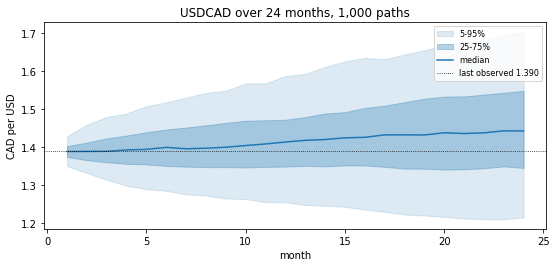

USDCAD               rate_diff               log_oil              
     0.05   0.50   0.95      0.05   0.50   0.95    0.05   0.50   0.95
t                                                                    
1   1.350  1.389  1.429     0.853  1.008  1.163   4.292  4.435  4.591
12  1.255  1.414  1.587     0.355  1.039  1.741   3.709  4.469  5.356
24  1.215  1.443  1.704     0.021  1.065  2.050   3.297  4.453  5.670

In [10]:
P = cv.simulate_paths(1000, 24, seed=1)
j = P.assets.index("log_fx"); fx = np.exp(P.array[:, :, j]); last = np.exp(data["log_fx"].iloc[-1])
q = np.quantile(fx, [0.05, 0.25, 0.5, 0.75, 0.95], axis=0)
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.fill_between(range(1, 25), q[0], q[4], color="tab:blue", alpha=0.15, label="5-95%"); ax.fill_between(range(1, 25), q[1], q[3], color="tab:blue", alpha=0.3, label="25-75%")
ax.plot(range(1, 25), q[2], color="tab:blue", label="median"); ax.axhline(last, color="black", lw=0.8, ls=":", label=f"last observed {last:.3f}")
ax.set_xlabel("month"); ax.set_ylabel("CAD per USD"); ax.set_title("USDCAD over 24 months, 1,000 paths"); ax.legend(fontsize=8); plt.show()
frame = P.to_frame(); frame["USDCAD"] = np.exp(frame["log_fx"])
frame.groupby("t")[["USDCAD", "rate_diff", "log_oil"]].quantile([0.05, 0.5, 0.95]).unstack().round(3).loc[[1, 12, 24]]

## A scenario on a parent

A scenario is a change of a parent's residual draw. Here oil falls by 30 percent over the first twelve months: a drift $\delta$ is added to the standardized oil innovation, $\tilde\varepsilon_{oil,t} = \varepsilon_{oil,t} + \delta$ for $t \le 12$, with $\delta = -0.30 / (12\,\sigma_{oil})$ so that the cumulated shift in log oil is $\sum_{t \le 12} \sigma_{oil}\,\delta = -0.30$, everything else drawn as before (the same residual matrix `E`, in the column order the inverse expects). The parents' paths change through the block's recursion; the child answers through $\boldsymbol\gamma$ at once, by $\gamma_{oil}\,\sigma_{oil}\,\delta$ per month while the drift lasts, and through $\kappa$ and $\boldsymbol\theta$ over time, its own innovation still drawn from the vine. Nothing is re-estimated. The table compares the medians of oil and of USDCAD across paths, baseline against scenario, at months 1, 3, 6, 12 and 24.

In [11]:
cols = cv.dynamics.columns                     # the history's column order, the one unfilter expects
E = cv.simulate(1000 * 24, seed=1, accept=False).loc[:, cols].values.reshape(1000, 24, len(cols))
base = cv.dynamics.unfilter(E)
blk = cv.dynamics.models[("rate_diff", "log_oil")]; sigma_oil = blk.sigma[blk.columns.index("log_oil")]
Es = E.copy(); Es[:, :12, cols.index("log_oil")] -= 0.30 / 12 / sigma_oil
shock = cv.dynamics.unfilter(Es)
jf, jo = cols.index("log_fx"), cols.index("log_oil")
tab = pd.DataFrame({"oil, median (baseline)": np.exp(np.median(base[:, :, jo], axis=0)), "oil, median (scenario)": np.exp(np.median(shock[:, :, jo], axis=0)),
                    "USDCAD, median (baseline)": np.exp(np.median(base[:, :, jf], axis=0)), "USDCAD, median (scenario)": np.exp(np.median(shock[:, :, jf], axis=0))},
                   index=range(1, 25)).loc[[1, 3, 6, 12, 24]].round(3)
tab

,"oil, median (baseline)","oil, median (scenario)","USDCAD, median (baseline)","USDCAD, median (scenario)"
1,84.392,82.308,1.389,1.391
3,85.429,77.929,1.389,1.400
6,83.442,68.463,1.400,1.422
12,87.288,57.898,1.414,1.455
24,85.846,56.103,1.443,1.461


The median path of USDCAD under the baseline and under the scenario. The gap between the two lines is the response of the exchange rate to the oil path alone, since the two runs share every other draw; it opens over the twelve months of the shock at the rate $\gamma_{oil}$ sets and then evolves with the long-run adjustment.

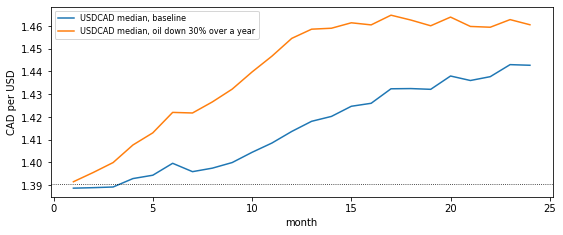

In [12]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(range(1, 25), np.exp(np.median(base[:, :, jf], axis=0)), label="USDCAD median, baseline"); ax.plot(range(1, 25), np.exp(np.median(shock[:, :, jf], axis=0)), label="USDCAD median, oil down 30% over a year")
ax.axhline(last, color="black", lw=0.8, ls=":"); ax.set_xlabel("month"); ax.set_ylabel("CAD per USD"); ax.legend(fontsize=8); plt.show()

## Without the structure: an AR(1) on the exchange rate alone

Filtering the exchange rate on its own with $s_t = c + \phi\, s_{t-1} + \sigma\, \varepsilon_t$ leaves the vine to carry whatever correlation the residuals show, and nothing else: no long-run relation, no response to oil beyond the residual correlation, and a level that reverts to the sample mean $c / (1 - \phi)$ at the rate $1 - \phi$ per month. The comparison measures what each filter carries with the correlation across paths of the 12-month changes,

$$\mathrm{Corr}\big(s^{(i)}_{12} - s^{(i)}_{1},\; z^{(i)}_{oil,12} - z^{(i)}_{oil,1}\big), \qquad i = 1, \dots, 1{,}000,$$

next to the quantiles of USDCAD at month 24. Under the structure the co-movement comes from $\boldsymbol\gamma$ and $\boldsymbol\theta$; under the AR(1) it comes only from the copula between the two innovations.

In [13]:
cv1 = CVineMarket(t, central="SPY", families="auto",
                  dynamics={("rate_diff", "log_oil"): "vecm(r=0,q=1)", "log_fx": "ar1", "SPY": "ar1-garch"}).fit()
P1 = cv1.simulate_paths(1000, 24, seed=1)
fx1 = np.exp(P1.array[:, :, P1.assets.index("log_fx")])
def corr_change(PP, name_a, name_b, t=12):
    a = PP.array[:, t - 1, PP.assets.index(name_a)] - PP.array[:, 0, PP.assets.index(name_a)]
    b = PP.array[:, t - 1, PP.assets.index(name_b)] - PP.array[:, 0, PP.assets.index(name_b)]
    return np.corrcoef(a, b)[0, 1]
pd.DataFrame({"structural": [np.median(fx[:, 23]), np.quantile(fx[:, 23], 0.05), np.quantile(fx[:, 23], 0.95), corr_change(P, "log_fx", "log_oil")],
              "AR(1) on log_fx": [np.median(fx1[:, 23]), np.quantile(fx1[:, 23], 0.05), np.quantile(fx1[:, 23], 0.95), corr_change(P1, "log_fx", "log_oil")]},
             index=["USDCAD median, month 24", "USDCAD 5%, month 24", "USDCAD 95%, month 24", "corr(12-month change of log USDCAD, of log oil)"]).round(3)

,structural,AR(1) on log_fx
"USDCAD median, month 24",1.443,1.380
"USDCAD 5%, month 24",1.215,1.209
"USDCAD 95%, month 24",1.704,1.586
"corr(12-month change of log USDCAD, of log oil)",-0.477,-0.471


## Save

`save` writes the market to JSON: the residual-layer targets, the Johnson SU parameters per column, the vine's edges, and the dynamics with the block's coefficients and state, the child's $(c, \kappa, \mathbf b, \boldsymbol\gamma, \phi, \hat\sigma)$ with its last $s$ and $\mathbf z$, and SPY's model. `load` rebuilds it without refitting, and the dependency order is recomputed from the equations.

In [14]:
cv.save("fx_market.json")
CVineMarket.load("fx_market.json").simulate_paths(3, 6, seed=2)

Paths(n_paths=3, horizon=6, assets=4, returns)

## Where to go next

`form='linear'` on returns is the same object without error correction, and
with `lags=0` it is the factor map of notebook 08. The yield-curve notebook uses
children that are deterministic functions of their parents.